In [1]:
import cv2, os, time
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
import torch

%matplotlib inline

### Get the best weight for each model

In [2]:
cwd = os.getcwd()
yolo_dirs = ['yolo8', 'yolo11', 'yolo9', 'yolo12']
gen_dir = [os.path.join(cwd, gen) for gen in yolo_dirs]
models_name = [os.listdir(model_dir) for model_dir in gen_dir if os.path.isdir(model_dir)]

model_dirs = []
for gen, models in zip(gen_dir, models_name):
    for model in models:
        path = os.path.join(gen, model)
        if os.path.isdir(path):
            model_dirs.append(path)
        
models_weight_path = [os.path.join(model_dir, "weights", "best.pt") for model_dir in model_dirs]
models_weight_path


['/home/kien/Desktop/projects/Amir_research/yolo/yolo8/yolov8m/weights/best.pt',
 '/home/kien/Desktop/projects/Amir_research/yolo/yolo8/yolov8n/weights/best.pt',
 '/home/kien/Desktop/projects/Amir_research/yolo/yolo8/yolov8l/weights/best.pt',
 '/home/kien/Desktop/projects/Amir_research/yolo/yolo8/yolov8x/weights/best.pt',
 '/home/kien/Desktop/projects/Amir_research/yolo/yolo8/yolov8s/weights/best.pt',
 '/home/kien/Desktop/projects/Amir_research/yolo/yolo11/yolo11l/weights/best.pt',
 '/home/kien/Desktop/projects/Amir_research/yolo/yolo11/yolo11n/weights/best.pt',
 '/home/kien/Desktop/projects/Amir_research/yolo/yolo11/yolo11s/weights/best.pt',
 '/home/kien/Desktop/projects/Amir_research/yolo/yolo11/yolo11m/weights/best.pt',
 '/home/kien/Desktop/projects/Amir_research/yolo/yolo11/yolo11x/weights/best.pt',
 '/home/kien/Desktop/projects/Amir_research/yolo/yolo9/yolov9e2/weights/best.pt',
 '/home/kien/Desktop/projects/Amir_research/yolo/yolo9/yolov9s/weights/best.pt',
 '/home/kien/Desktop/p

### Load all yolo models into DF

In [3]:
from collections import defaultdict
dic = defaultdict(list)

for model_path in models_weight_path:
    
    str_split = model_path.split("/")
    dic["gen"].append(str_split[7])
    dic["name"].append(str_split[8])
    dic["model"].append(YOLO(model_path))

    
df = pd.DataFrame(dic)
df


,gen,name,model
0,yolo8,yolov8m,YOLO(\n (model): DetectionModel(\n (model)...
1,yolo8,yolov8n,YOLO(\n (model): DetectionModel(\n (model)...
2,yolo8,yolov8l,YOLO(\n (model): DetectionModel(\n (model)...
3,yolo8,yolov8x,YOLO(\n (model): DetectionModel(\n (model)...
4,yolo8,yolov8s,YOLO(\n (model): DetectionModel(\n (model)...
5,yolo11,yolo11l,YOLO(\n (model): DetectionModel(\n (model)...
6,yolo11,yolo11n,YOLO(\n (model): DetectionModel(\n (model)...
7,yolo11,yolo11s,YOLO(\n (model): DetectionModel(\n (model)...
8,yolo11,yolo11m,YOLO(\n (model): DetectionModel(\n (model)...
9,yolo11,yolo11x,YOLO(\n (model): DetectionModel(\n (model)...


### EVAL

In [4]:
import os, gc, torch

results = []
data_dir = os.path.join("..","pretrain_models","data","mobile detection.v7i.yolov11","data.yaml")

VAL_KW = dict(
    data=data_dir,
    split="test",
    imgsz=640,
    iou=0.50,
    conf=0.001,
    batch=1,
    device=0,
    half=True,      
    workers=0,
    verbose=False,
)


with torch.no_grad():
    for i, yolo_obj in df["model"].items():
        try:
            # Make sure it's on GPU only while we need it
            yolo_obj.model.to("cuda").eval()

            res = yolo_obj.val(**VAL_KW)

            results.append(res)
        finally:
            # Move OFF GPU, break all refs, and clear caches
            try:
                yolo_obj.model.to("cpu")
            except Exception:
                pass
            df.at[i, "model"] = None    # <- break the DF reference
            del yolo_obj
            gc.collect()
            torch.cuda.synchronize()
            torch.cuda.empty_cache()

Ultralytics 8.3.195 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080, 9864MiB)
Model summary (fused): 92 layers, 25,842,076 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1641.7±587.1 MB/s, size: 39.9 KB)
val: Scanning /home/kien/Desktop/projects/Amir_research/pretrain_models/data/mobile detection.v7i.yolov11/test/labels.cache... 270 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 270/270 619.5Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 270/270 75.3it/s 3.6s0.1s
                   all        270        271      0.959      0.926      0.963      0.608
Speed: 0.3ms preprocess, 7.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /home/kien/Desktop/projects/Amir_research/yolo/runs/detect/val
Ultralytics 8.3.195 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3080, 9864MiB)
Model summary (fused): 72 layers, 3,006,428 parame

### Get the Metrics that i want

In [5]:
df = df.drop(columns=["model"])
df["map50_95"] = [result.box.map for result in results]
df["speed"] = [sum(result.speed.values()) for result in results]
df["s_per_pic"] = df.speed/270
df["fps"] = 1/df["s_per_pic"]

In [6]:
df

,gen,name,map50_95,speed,s_per_pic,fps
0,yolo8,yolov8m,0.607781,8.612888,0.031900,31.348368
1,yolo8,yolov8n,0.599128,6.662799,0.024677,40.523512
2,yolo8,yolov8l,0.616803,10.406087,0.038541,25.946353
3,yolo8,yolov8x,0.626444,16.938544,0.062735,15.939977
4,yolo8,yolov8s,0.598078,6.206764,0.022988,43.500931
5,yolo11,yolo11l,0.618033,19.420865,0.071929,13.902573
6,yolo11,yolo11n,0.590898,13.486247,0.049949,20.020395
7,yolo11,yolo11s,0.602350,9.198367,0.034068,29.353037
8,yolo11,yolo11m,0.612337,9.507070,0.035211,28.399918
9,yolo11,yolo11x,0.592882,20.327080,0.075285,13.282774


In [ ]:
df.to_csv("./runs/test_results.csv", index=False)

In [ ]:
df = pd.read_csv("./runs/test_results.csv")
df

,gen,name,map50_95,speed,s_per_pic,fps
0,yolo8,yolov8m,0.607781,8.612888,0.031900,31.348368
1,yolo8,yolov8n,0.599128,6.662799,0.024677,40.523512
2,yolo8,yolov8l,0.616803,10.406087,0.038541,25.946353
3,yolo8,yolov8x,0.626444,16.938544,0.062735,15.939977
4,yolo8,yolov8s,0.598078,6.206764,0.022988,43.500931
5,yolo11,yolo11l,0.618033,19.420865,0.071929,13.902573
6,yolo11,yolo11n,0.590898,13.486247,0.049949,20.020395
7,yolo11,yolo11s,0.602350,9.198367,0.034068,29.353037
8,yolo11,yolo11m,0.612337,9.507070,0.035211,28.399918
9,yolo11,yolo11x,0.592882,20.327080,0.075285,13.282774


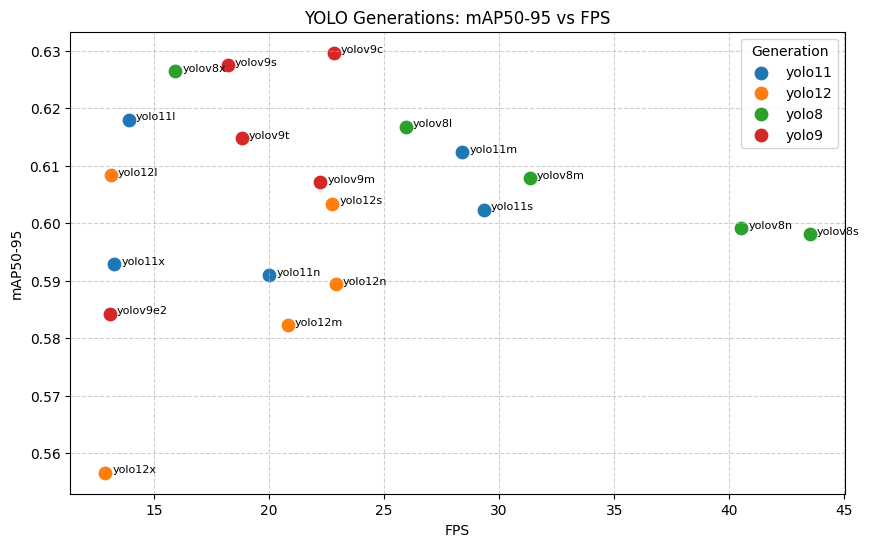

In [28]:
# Plot
plt.figure(figsize=(10,6))
for gen, group in df.groupby("gen"):
    plt.scatter(group["fps"], group["map50_95"], label=gen, s=80)
    for i, row in group.iterrows():
        plt.text(row["fps"] + 0.3, row["map50_95"], row["name"], fontsize=8)

plt.xlabel("FPS")
plt.ylabel("mAP50-95")
plt.title("YOLO Generations: mAP50-95 vs FPS")
plt.legend(title="Generation")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [ ]:

# Load a pretrained YOLO11n model
model = YOLO("./gen2/yolov11m/weights/last.pt")

# Define path to video file
source = "../my_video/incabin/GOPR0242.MP4"

# Run inference on the source
results = model.predict(source, stream=True, save=True, visualize=True)

### Use 8l, 8m, 11s, 11m on my video

In [ ]:

from ultralytics import YOLO

# model_names = ["yolov8l", "yolov8m", "yolo11s", "yolo11m"]
model_names = ["yolov11m scratch"]

model_weights = [
    # "yolo8/yolov8l/weights/best.pt", 
    # "yolo8/yolov8m/weights/best.pt", 
    # "yolo11/yolo11s/weights/best.pt", 
    # "yolo11/yolo11m/weights/best.pt"
    "./gen2/yolov11m_no_pretrain_300/weights/best.pt"
]

vid_path = "../my_video/incabin"

for vid in os.listdir(vid_path): 

    for name, weight in zip(model_names, model_weights):

        model = YOLO(weight)
        cap = cv2.VideoCapture(os.path.join(vid_path, vid))
        out_path = "./runs/video_output/" + vid + "_" + name + "_output.mp4"  

        # Get video properties
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        # Define the codec and create VideoWriter object
        # out = cv2.VideoWriter(
        #     out_path,
        #     cv2.VideoWriter_fourcc(*"mp4v"),  # use mp4 codec
        #     fps,
        #     (width, height)
        # )

        # Loop through the video frames
        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                break

            start_time = time.time()

            # Run YOLO inference
            results = model(frame, conf=0.40, max_det=2)
                            #stream_buffer=True, agnostic_nms=True)

            # Visualize results
            annotated_frame = results[0].plot()

            # Calculate inference FPS
            inf_time = time.time() - start_time
            inf_fps = 1 / inf_time if inf_time > 0 else 0

        # Put model name (top-left corner)
            cv2.putText(
                annotated_frame,
                f"Model: {name}",
                (20, 40),  # position
                cv2.FONT_HERSHEY_SIMPLEX,
                1.2,
                (255, 255, 0),  # cyan
                2,
                cv2.LINE_AA
            )

            # Put FPS just below the model name
            cv2.putText(
                annotated_frame,
                f"FPS: {inf_fps:.2f}",
                (20, 80),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.2,
                (0, 255, 0),
                2,
                cv2.LINE_AA
            )

            # Write annotated frame to output
            # out.write(annotated_frame)

            # Optionally show
            cv2.imshow("YOLO Inference", annotated_frame)
            if cv2.waitKey(1) & 0xFF == ord("q"):
                break
        cap.release()
        # out.release()
        cv2.destroyAllWindows()



0: 384x640 (no detections), 110.2ms
Speed: 2.7ms preprocess, 110.2ms inference, 49.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 11.1ms
Speed: 2.5ms preprocess, 11.1ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 10.2ms
Speed: 1.5ms preprocess, 10.2ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 10.5ms
Speed: 1.4ms preprocess, 10.5ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 9.5ms
Speed: 1.7ms preprocess, 9.5ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)


qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/kien/venvs/torch-rocm/lib/python3.12/site-packages/cv2/qt/plugins"



0: 384x640 (no detections), 9.8ms
Speed: 1.5ms preprocess, 9.8ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 13.9ms
Speed: 2.2ms preprocess, 13.9ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 9.4ms
Speed: 1.4ms preprocess, 9.4ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 9.6ms
Speed: 1.4ms preprocess, 9.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 10.5ms
Speed: 1.4ms preprocess, 10.5ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 10.3ms
Speed: 1.6ms preprocess, 10.3ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 10.9ms
Speed: 2.6ms preprocess, 10.9ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 10.3ms
Speed: 1.5ms preprocess, 10.3ms inferen

In [ ]:
import os
import cv2
import time
from ultralytics import YOLO

# model_names = ["yolov11m scratch"]
# model_weights = ["./gen2/yolov11m_no_pretrain_300/weights/best.pt"]
model_names = ["yolov11m_balancedDS"]
model_weights = ["../yolo_no_weight/runs/detect/yolov11m_no_pretrain_300/weights/best.pt"]
vid_path = "../my_video/incabin"

output_fps = 25  # desired output frame rate

for vid in os.listdir(vid_path): 
    for name, weight in zip(model_names, model_weights):
        model = YOLO(weight)
        cap = cv2.VideoCapture(os.path.join(vid_path, vid))
        out_path = f"./runs/video_output/{os.path.splitext(vid)[0]}_{name}_output.mp4"

        # Get input video properties
        in_fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        # Define writer with target 25 fps
        out = cv2.VideoWriter(
            out_path,
            cv2.VideoWriter_fourcc(*"mp4v"),
            output_fps,
            (width, height)
        )

        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                break

            start_time = time.time()
            results = model(frame, conf=0.5)
            annotated_frame = results[0].plot()

            inf_time = time.time() - start_time
            inf_fps = 1 / inf_time if inf_time > 0 else 0

            cv2.putText(annotated_frame, f"Model: {name}", (20, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 0), 2, cv2.LINE_AA)
            cv2.putText(annotated_frame, f"Infer FPS: {inf_fps:.2f}", (20, 80),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2, cv2.LINE_AA)

            # Write to output (slowed to 25 fps)
            out.write(annotated_frame)

            # # Optional: show live inference
            # cv2.imshow("YOLO Inference", annotated_frame)
            # if cv2.waitKey(1) & 0xFF == ord("q"):
            #     break

        cap.release()
        out.release()
        # cv2.destroyAllWindows()



0: 384x640 (no detections), 9.5ms
Speed: 1.7ms preprocess, 9.5ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 8.3ms
Speed: 1.5ms preprocess, 8.3ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 8.0ms
Speed: 1.6ms preprocess, 8.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 8.2ms
Speed: 1.4ms preprocess, 8.2ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 8.4ms
Speed: 1.6ms preprocess, 8.4ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 8.2ms
Speed: 1.4ms preprocess, 8.2ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 8.1ms
Speed: 1.7ms preprocess, 8.1ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 8.3ms
Speed: 1.5ms preprocess, 8.3ms inference, 0.5ms 

error: OpenCV(4.12.0) /io/opencv/modules/highgui/src/window.cpp:1295: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvDestroyAllWindows'
